In [11]:
import xtrack as xt
import xpart as xp
import xfields as xf 
import xobjects as xo
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt
import json

In [ ]:
design=
config=
mode=

In [17]:
line = xt.Line.from_json('/home/mwatson/Documents/laughing-octo-bassoon/Polarization and tracking/D1 C1/D1_C1_corrections.json')


line.configure_radiation('mean')


line.discard_tracker()
line.build_tracker()

tw = line.twiss(method='6d', radiation_integrals=True, eneloss_and_damping=True,
                   spin=True, polarization=True)

print(f"Global Coupling Strength (|C-|): {tw.c_minus:.5f}")
print(f"Horizontal Emittance (ex): {tw.eq_gemitt_x:.5e} m")
print(f"Vertical Emittance (ey): {tw.eq_gemitt_y:.5e} m")
print(f"Emittance Ratio (ey/ex): {tw.eq_gemitt_y / tw.eq_gemitt_x:.4f}")

print(tw.cols)
np.random.seed(0)
particles = xp.generate_matched_gaussian_bunch(
    line=line,
    nemitt_x=tw.eq_nemitt_x,
    nemitt_y=tw.eq_nemitt_y,
    sigma_z=np.sqrt(tw.eq_gemitt_zeta * tw.bets0),
    num_particles=300)
# Add stable phase
particles.zeta += tw.zeta[0]
particles.delta += tw.delta[0]

# Initialize spin of all particles along n0
particles.spin_x = tw.spin_x[0]
particles.spin_y = tw.spin_y[0]
particles.spin_z = tw.spin_z[0]

# Simulate bunch evolution with stochastic photon emission
line.configure_spin('auto')
line.configure_radiation(model='quantum')

# Enable parallelization
line.discard_tracker()
line.build_tracker(_context=xo.ContextCpu(omp_num_threads='auto'))

# Track
num_turns=10000
line.track(particles, num_turns=num_turns, turn_by_turn_monitor=True,
           with_progress=10)
mon = line.record_last_track


# Fit depolarization time
mask_alive = mon.state > 0
pol_x = mon.spin_x.sum(axis=0)/mask_alive.sum(axis=0)
pol_y = mon.spin_y.sum(axis=0)/mask_alive.sum(axis=0)
pol_z = mon.spin_z.sum(axis=0)/mask_alive.sum(axis=0)
pol = np.sqrt(pol_x**2 + pol_y**2 + pol_z**2)

i_start = 3 # Skip a few turns (small initial mismatch)
pol_to_fit = pol[i_start:]/pol[i_start]

turns = np.arange(len(pol_to_fit))
slope, intercept, r_value, p_value, std_err = linregress(turns, pol_to_fit)
# Calculate depolarization time
t_dep_turns = -1 / slope


Loading line from dict:   0%|          | 0/6439 [00:00<?, ?it/s]

Done loading line from dict.           
Done loading line from dict.           
Done loading line from dict.           
Global Coupling Strength (|C-|): 0.01049
Horizontal Emittance (ex): 2.91911e-08 m
Vertical Emittance (ey): 3.79756e-10 m
Emittance Ratio (ey/ex): 0.0130
ColView: name s x px y py zeta delta ptau W_matrix kin_px kin_py kin_ps kin_xprime kin_yprime env_name spin_x spin_y spin_z betx bety alfx alfy gamx gamy dx dpx dy dpy dx_zeta dpx_zeta dy_zeta dpy_zeta betx1 bety1 betx2 bety2 alfx1 alfy1 alfx2 alfy2 gamx1 gamy1 gamx2 gamy2 mux muy muzeta nux nuy nuzeta phix phiy phizeta c_minus_re c_minus_im c_r1 c_r2 c_phi1 c_phi2 dmux dmuy dzeta bx_chrom by_chrom ax_chrom ay_chrom wx_chrom wy_chrom ddx ddpx ddy ddpy angle_rad rot_s_rad length radiation_flag k0l k1l k2l k3l k4l k5l k0sl k1sl k2sl k3sl k4sl k5sl angle_rad rot_s_rad hkick vkick ks length _angle_force_body element_type isthick parent_name rad_int_curly_hx rad_int_curly_hy rad_int_i1x_integrand rad_int_i1y_integrand rad_

KeyboardInterrupt: 

0.17858358376041925
0.039527442922526856
Sokolov-Ternov Build-up Time: 883.29 seconds (1210806083.5 turns)


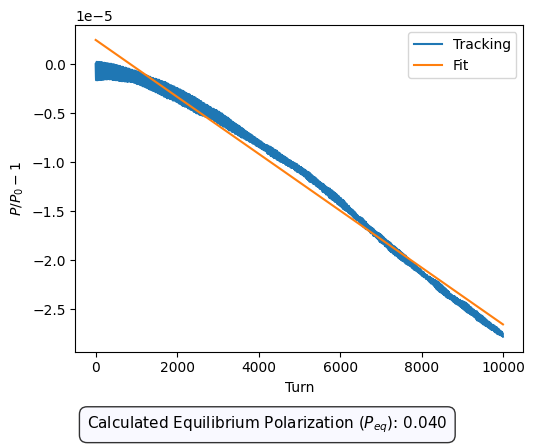

In [18]:

# Plot polarization decay and fit
plt.figure()
plt.plot(pol_to_fit-1, label='Tracking')
plt.plot(turns, intercept*np.exp(-turns/t_dep_turns) - 1, label='Fit')
plt.ylabel(r'$P/P_0 - 1$')
plt.xlabel('Turn')
plt.subplots_adjust(left=.2)
plt.legend()

# Compute equilibrium polarization
p_inf = tw['spin_polarization_inf_no_depol']
print(p_inf)
t_pol_turns = tw['spin_t_pol_component_s']/tw.T_rev0

p_eq = p_inf * 1 / (1 + t_pol_turns/t_dep_turns)
print(p_eq)
plt.subplots_adjust(bottom=0.2)
plt.figtext(0.5, 0.04, f"Calculated Equilibrium Polarization ($P_{{eq}}$): {p_eq:.3f}", 
            ha="center", fontsize=11, 
            bbox=dict(facecolor='ghostwhite', alpha=0.8, boxstyle='round,pad=0.5'))

# Time constant in seconds
t_pol_seconds = tw['spin_t_pol_component_s']

# Time constant in turns
t_pol_turns = tw['spin_t_pol_component_s'] / tw.T_rev0

print(f"Sokolov-Ternov Build-up Time: {t_pol_seconds:.2f} seconds ({t_pol_turns:.1f} turns)")


In [14]:
print(tw.qx)
print(tw.qy)
print(tw.qs)


15.438032128027542
15.383437090824641
0.03664378390292222


In [15]:
import numpy as np
import xtrack as xt
import xpart as xp
import xobjects as xo
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Load the line
line = xt.Line.from_json('/home/mwatson/Documents/laughing-octo-bassoon/Polarization and tracking/D1 C1/D1_C1_corrections.json')

# Define the seeds you want to sample
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
bunches = []

line.configure_radiation('mean')
line.build_tracker()  # Single-threaded by default, safe for Twiss & Matching

tw = line.twiss(method='6d', radiation_integrals=True, eneloss_and_damping=True,
                spin=True, polarization=True)

print("Generating matched bunches for all random seeds...")
for seed in seeds:
    np.random.seed(seed)
    
    # Standard, robust matching works perfectly here
    particles = xp.generate_matched_gaussian_bunch(
        line=line,
        nemitt_x=tw.eq_nemitt_x,
        nemitt_y=tw.eq_nemitt_y,
        sigma_z=np.sqrt(tw.eq_gemitt_zeta * tw.bets0),
        num_particles=300
    )
    
    # Add stable phase shifts
    particles.zeta += tw.zeta[0]
    particles.delta += tw.delta[0]

    # Initialize spin of all particles along the periodic solution n0
    particles.spin_x = tw.spin_x[0]
    particles.spin_y = tw.spin_y[0]
    particles.spin_z = tw.spin_z[0]
    
    bunches.append(particles)

# Extract global invariant polarization properties from the optics
p_inf = tw['spin_polarization_inf_no_depol']
t_pol_turns = tw['spin_t_pol_component_s'] / tw.T_rev0


line.configure_spin('auto')
line.configure_radiation(model='quantum')

# Discard single-threaded tracker and recompile once with OpenMP for tracking speed
line.discard_tracker()
line.build_tracker(_context=xo.ContextCpu(omp_num_threads='auto'))

p_eq_results = []
num_turns = 10000

for seed, particles in zip(seeds, bunches):
    print(f"\n--- Tracking Bunch for Seed {seed} ---")
    line.track(particles, num_turns=num_turns, turn_by_turn_monitor=True)
    mon = line.record_last_track
    
    # Fit depolarization time
    mask_alive = mon.state > 0
    pol_x = mon.spin_x.sum(axis=0) / mask_alive.sum(axis=0)
    pol_y = mon.spin_y.sum(axis=0) / mask_alive.sum(axis=0)
    pol_z = mon.spin_z.sum(axis=0) / mask_alive.sum(axis=0)
    pol = np.sqrt(pol_x**2 + pol_y**2 + pol_z**2)

    i_start = 3  # Skip initial turn transients
    pol_to_fit = pol[i_start:] / pol[i_start]

    turns = np.arange(len(pol_to_fit))
    slope, intercept, r_value, p_value, std_err = linregress(turns, pol_to_fit)
    t_dep_turns = -1 / slope
    
    # Calculate equilibrium polarization
    p_eq = p_inf * 1 / (1 + t_pol_turns / t_dep_turns)
    p_eq_results.append(p_eq)
    
    print(f"Seed {seed} Complete: t_dep = {t_dep_turns:.1f} turns, P_eq = {p_eq:.4f}")


# 1. Frequency Distribution Histogram
plt.figure()
plt.hist(p_eq_results, bins=5, edgecolor='black', color='skyblue', alpha=0.8)
plt.xlabel(r'Equilibrium Polarization $P_{\text{eq}}$')
plt.ylabel('Frequency (Count)')
plt.title(r'Histogram of $P_{\text{eq}}$ Variation Across Seeds')
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig('equilibrium_polarization_histogram.png')

# 2. Scatter Plot against Seed IDs
plt.figure()
plt.scatter(seeds, p_eq_results, color='crimson', marker='o', s=100, zorder=3)
plt.plot(seeds, p_eq_results, color='gray', linestyle='--', alpha=0.5, zorder=2)
plt.xlabel('Random Seed')
plt.ylabel(r'Equilibrium Polarization $P_{\text{eq}}$')
plt.title(r'$P_{\text{eq}}$ Versus Seed Number')
plt.xticks(seeds)
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig('polarization_against_seed.png')

Loading line from dict:   0%|          | 0/6439 [00:00<?, ?it/s]

Done loading line from dict.           
Done loading line from dict.           
Done loading line from dict.           
The line already has an associated tracker
Generating matched bunches for all random seeds...
Compiling ContextCpu kernels...


KeyboardInterrupt: 